In [3]:
!pip install librosa

  Using cached librosa-0.10.2.post1-py3-none-any.whl.metadata (8.6 kB)
  Using cached audioread-3.0.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-0.5.0.post1-cp312-abi3-win_amd64.whl.metadata (5.6 kB)
Using cached librosa-0.10.2.post1-py3-none-any.whl (260 kB)
Using cached audioread-3.0.1-py3-none-any.whl (23 kB)
Using cached pooch-1.8.2-py3-none-any.whl (64 kB)
Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
Using cached soxr-0.5.0.post1-cp312-abi3-win_amd64.whl (164 kB)


In [5]:

from librosa import load
from IPython.display import Audio
from librosa.display import waveshow
import matplotlib.pyplot as plt
from scipy.io.wavfile import read
from librosa.feature import mfcc
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
from sklearn.metrics import ConfusionMatrixDisplay

In [11]:
data,sample_rate = load('C:/Dataset/31325-3-4-0.wav')
type(data),data.shape,sample_rate

(numpy.ndarray, (88200,), 22050)

In [15]:
data,sample_rate = load('C:/Dataset/96921-9-0-17.wav',sr=44100,mono=False)
type(data),data.shape,sample_rate

(numpy.ndarray, (2, 176400), 44100)

In [17]:
data

array([[0.03683472, 0.02578735, 0.01928711, ..., 0.06964111, 0.07128906,
        0.06692505],
       [0.02819824, 0.01599121, 0.01751709, ..., 0.06491089, 0.06271362,
        0.06072998]], dtype=float32)

In [21]:
Audio(data=data,rate=sample_rate)#

In [132]:
#sr,data = read('C:/Dataset/9674-1-0-0.wav')
#y.shape,sr

In [25]:
data

array([[-3987,  1070],
       [-5085,   928],
       [-6244,   820],
       ...,
       [-7854,  7694],
       [-7561,  7405],
       [-7185,  6372]], dtype=int16)

In [130]:
np.mean(np.transpose(mfcc(y=data,sr=sample_rate,n_mfcc=20)),axis=0)

array([-288.02017   ,  146.36894   ,  -43.75777   ,  -10.032436  ,
          3.8740609 ,   10.684882  ,   -8.620944  ,    0.40861017,
         -3.2387857 ,   -1.4452341 ,   -1.3546412 ,    3.8591163 ,
         -1.8967944 ,    2.3597596 ,   -6.684929  ,   -7.6315827 ,
         -6.9448333 ,    7.9461393 ,    3.6507244 ,   -6.5233817 ],
      dtype=float32)

In [29]:
from librosa.feature import mfcc

In [33]:
#features=mfcc(y=data,sr=22050,n_mfcc=20) # fix
#features.shape

In [35]:
samples=pd.read_csv("C:/Users/Suraj/Downloads/UrbanSound8K/UrbanSound8K/metadata/UrbanSound8K.csv")

In [37]:
samples.sample()

,slice_file_name,fsID,start,end,salience,fold,classID,class
775,115240-9-0-16.wav,115240,13.328996,17.328996,1,8,9,street_music


In [39]:
samples[:10]

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
5,100263-2-0-143.wav,100263,71.500000,75.500000,1,5,2,children_playing
6,100263-2-0-161.wav,100263,80.500000,84.500000,1,5,2,children_playing
7,100263-2-0-3.wav,100263,1.500000,5.500000,1,5,2,children_playing
8,100263-2-0-36.wav,100263,18.000000,22.000000,1,5,2,children_playing
9,100648-1-0-0.wav,100648,4.823402,5.471927,2,10,1,car_horn


In [41]:
samples.shape

(8732, 8)

In [43]:
samples['class'].value_counts().sort_index()

class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64

In [45]:
k = np.random.randint(8732)
folder_path ="C:/Users/Suraj/Downloads/UrbanSound8K/UrbanSound8K/audio/fold"
file_name = samples.slice_file_name[k]
fold = samples.fold[k]
fold,file_name

(2, '102871-8-0-14.wav')

In [47]:
file_path = folder_path + str(fold) + '/' + file_name
print(file_path)
data,sample_rate = load(file_path)
np.mean(np.transpose(mfcc(y=data,sr=sample_rate,n_mfcc=20)),axis=0)

C:/Users/Suraj/Downloads/UrbanSound8K/UrbanSound8K/audio/fold2/102871-8-0-14.wav


array([-288.02017   ,  146.36894   ,  -43.75777   ,  -10.032436  ,
          3.8740609 ,   10.684882  ,   -8.620944  ,    0.40861017,
         -3.2387857 ,   -1.4452341 ,   -1.3546412 ,    3.8591163 ,
         -1.8967944 ,    2.3597596 ,   -6.684929  ,   -7.6315827 ,
         -6.9448333 ,    7.9461393 ,    3.6507244 ,   -6.5233817 ],
      dtype=float32)

In [49]:
def features_extractor(file_name):
    data,sample_rate = load(file_name)
    features = mfcc(y=data,sr=sample_rate,n_mfcc=20)
    features_scaled = np.mean(np.transpose(features),axis=0)
    return features_scaled

In [51]:
features_extractor(file_path)

array([-288.02017   ,  146.36894   ,  -43.75777   ,  -10.032436  ,
          3.8740609 ,   10.684882  ,   -8.620944  ,    0.40861017,
         -3.2387857 ,   -1.4452341 ,   -1.3546412 ,    3.8591163 ,
         -1.8967944 ,    2.3597596 ,   -6.684929  ,   -7.6315827 ,
         -6.9448333 ,    7.9461393 ,    3.6507244 ,   -6.5233817 ],
      dtype=float32)

In [53]:
audio_folder_path = 'C:/Users/Suraj/Downloads/UrbanSound8K/UrbanSound8K/audio/'
extracted_features=[]
for ix,r in tqdm(samples.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_folder_path), 'fold' + str(r.fold) , r.slice_file_name)
    features = features_extractor(file_name)
    label=r['class']
    extracted_features.append([features,label])

3552it [01:21, 43.91it/s]C:\Users\Suraj\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8324it [03:07, 55.83it/s]C:\Users\Suraj\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
C:\Users\Suraj\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [03:16, 44.46it/s]


In [ ]:
#tkdm

In [54]:
len(extracted_features)

8732

In [57]:
extracted_features[0]

[array([-211.93698  ,   62.581207 , -122.81313  ,  -60.745293 ,
         -13.89376  ,  -29.789831 ,   -3.978875 ,   11.682742 ,
          12.963828 ,    8.336421 ,   -6.5298195,   -2.9961064,
         -12.88795  ,    5.885933 ,   -2.4752254,   -4.4083114,
         -15.014478 ,   -0.9439967,   -2.5799105,    6.0982966],
       dtype=float32),
 'dog_bark']

In [59]:
features = [i[0] for i in extracted_features]
labels = [i[1] for i in extracted_features]

In [61]:
len(features),len(labels)

(8732, 8732)

In [63]:
df = pd.DataFrame(features)
df['labels'] = labels

In [65]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,labels
0,-211.936981,62.581207,-122.813133,-60.745293,-13.893760,-29.789831,-3.978875,11.682742,12.963828,8.336421,...,-2.996106,-12.887950,5.885933,-2.475225,-4.408311,-15.014478,-0.943997,-2.579911,6.098297,dog_bark
1,-417.005188,99.336624,-42.995586,51.073326,9.853778,7.969693,11.197088,1.929117,7.030397,4.270228,...,13.890946,-2.764493,7.272555,5.534419,1.869291,1.725747,7.038669,-2.442267,3.473614,children_playing
2,-452.393158,112.362534,-37.578068,43.195862,8.631845,15.379366,16.882149,1.233048,6.833122,3.900115,...,8.300045,1.904139,6.658551,3.820611,2.901616,-3.597533,0.822255,-0.118685,9.371599,children_playing
3,-406.479218,91.196602,-25.043558,42.784519,11.586843,5.054164,12.431632,-1.599949,6.656064,1.442355,...,14.211005,0.434271,6.992811,0.463175,-0.498952,3.337569,4.208089,2.285111,3.382271,children_playing
4,-439.638733,103.862228,-42.658787,50.690277,12.209422,15.873465,11.729268,1.533585,11.292244,2.548621,...,10.374461,2.101837,4.698793,6.547027,5.372394,-2.190753,1.980403,-4.660390,9.253263,children_playing


In [67]:
df.to_csv("C:/Users/Suraj/Downloads/UrbanSound8K/UrbanSound8K/metadata/UrbanSound8K.csv",sep=',',header=False,index=False)

In [69]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [71]:
y.value_counts().sort_index()

labels
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

In [79]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1000,stratify=y) # 1000 audio file test_size
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((7732, 20), (1000, 20), (7732,), (1000,))

In [81]:
y_train.isna().sum()

0

In [83]:
clf = KNeighborsClassifier(weights='distance')
clf.fit(X_train,y_train)
y_predict = clf.predict(X_test)

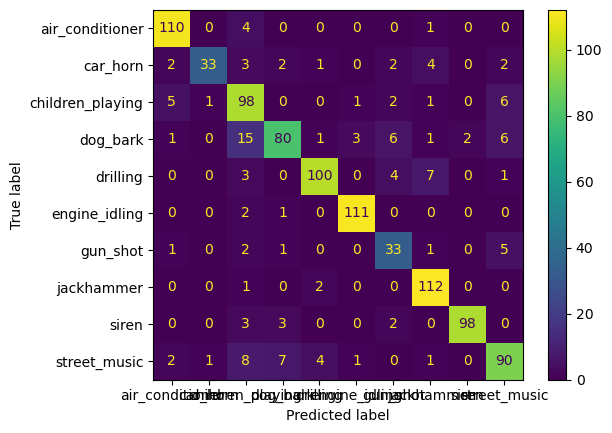

In [87]:
ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test)

In [89]:
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X_train,y_train)
clf.score(X_test,y_test)

0.709

In [91]:
clf.predict(X_test)

array(['air_conditioner', 'dog_bark', 'jackhammer', 'jackhammer',
       'dog_bark', 'air_conditioner', 'siren', 'engine_idling',
       'dog_bark', 'drilling', 'street_music', 'siren', 'engine_idling',
       'siren', 'car_horn', 'engine_idling', 'street_music', 'siren',
       'dog_bark', 'jackhammer', 'jackhammer', 'children_playing',
       'engine_idling', 'engine_idling', 'children_playing', 'dog_bark',
       'gun_shot', 'air_conditioner', 'street_music', 'children_playing',
       'gun_shot', 'gun_shot', 'jackhammer', 'siren', 'street_music',
       'gun_shot', 'siren', 'drilling', 'siren', 'drilling',
       'children_playing', 'jackhammer', 'street_music', 'siren',
       'dog_bark', 'jackhammer', 'children_playing', 'engine_idling',
       'street_music', 'siren', 'air_conditioner', 'jackhammer',
       'air_conditioner', 'dog_bark', 'air_conditioner', 'drilling',
       'children_playing', 'siren', 'street_music', 'drilling',
       'dog_bark', 'dog_bark', 'dog_bark', 'sire

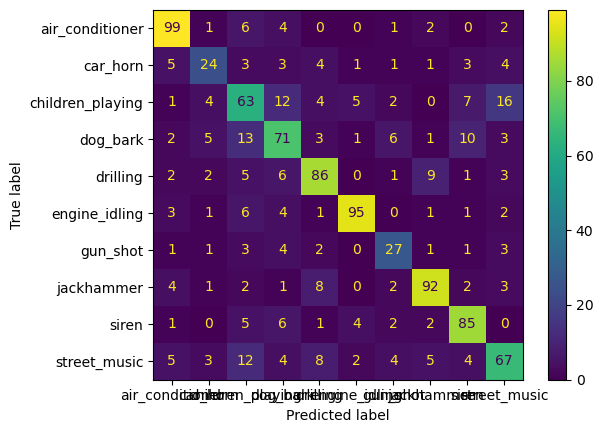

In [93]:
clf.predict(X_test)
ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test)
plt.show()

In [95]:
y_predict = clf.predict(X_test)
confusion_matrix(y_test,y_predict)

array([[99,  1,  6,  4,  0,  0,  1,  2,  0,  2],
       [ 5, 24,  3,  3,  4,  1,  1,  1,  3,  4],
       [ 1,  4, 63, 12,  4,  5,  2,  0,  7, 16],
       [ 2,  5, 13, 71,  3,  1,  6,  1, 10,  3],
       [ 2,  2,  5,  6, 86,  0,  1,  9,  1,  3],
       [ 3,  1,  6,  4,  1, 95,  0,  1,  1,  2],
       [ 1,  1,  3,  4,  2,  0, 27,  1,  1,  3],
       [ 4,  1,  2,  1,  8,  0,  2, 92,  2,  3],
       [ 1,  0,  5,  6,  1,  4,  2,  2, 85,  0],
       [ 5,  3, 12,  4,  8,  2,  4,  5,  4, 67]], dtype=int64)

In [102]:
!pip install keras tensorflow

In [104]:
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Dense,Activation
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

In [106]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [108]:
y = pd.get_dummies(y).astype('int32')
y

,air_conditioner,car_horn,children_playing,dog_bark,drilling,engine_idling,gun_shot,jackhammer,siren,street_music
0,0,0,0,1,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8727,0,1,0,0,0,0,0,0,0,0
8728,0,1,0,0,0,0,0,0,0,0
8729,0,1,0,0,0,0,0,0,0,0
8730,0,1,0,0,0,0,0,0,0,0


In [110]:
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=1000)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((7732, 20), (1000, 20), (7732, 10), (1000, 10))

In [112]:
y_test.sum()

air_conditioner     114
car_horn             49
children_playing    114
dog_bark            115
drilling            115
engine_idling       115
gun_shot             43
jackhammer          115
siren               106
street_music        114
dtype: int64

In [114]:
model = Sequential()

model.add(Dense(100,input_shape=(20,)))
model.add(Activation('relu'))

model.add(Dense(200))
model.add(Activation('relu'))

model.add(Dense(400))
model.add(Activation('relu'))
          
model.add(Dense(10))
model.add(Activation('softmax'))

model.summary()

C:\Users\Suraj\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 400)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         4,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,710 (416.84 KB)

 Trainable params: 106,710 (416.84 KB)

 Non-trainable params: 0 (0.00 B)

In [116]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [118]:
model.fit(X_train,y_train,epochs=100,validation_split=0.1,batch_size=64)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2792 - loss: 5.5391 - val_accuracy: 0.5284 - val_loss: 1.4885
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5394 - loss: 1.3876 - val_accuracy: 0.6344 - val_loss: 1.1121
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6120 - loss: 1.1934 - val_accuracy: 0.6486 - val_loss: 1.0300
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6703 - loss: 1.0013 - val_accuracy: 0.6848 - val_loss: 0.9720
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7232 - loss: 0.8696 - val_accuracy: 0.7442 - val_loss: 0.8231
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7345 - loss: 0.8016 - val_accuracy: 0.7313 - val_loss: 0.8112
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7708 - loss: 0.6969 - val_accuracy: 0.7713 - val_loss: 0.7133
Epoch 8/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8048 - loss: 0.6032 - val_acc

In [119]:
model.evaluate(X_test,y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9125 - loss: 0.5399


[0.5937105417251587, 0.9179999828338623]

In [120]:
y_predict = np.array([np.argmax(i) for i in model.predict(X_test)])
y_predict

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([9, 7, 2, 0, 5, 8, 3, 4, 9, 8, 4, 5, 3, 5, 4, 5, 6, 5, 8, 5, 2, 5,
       8, 4, 3, 3, 8, 9, 2, 5, 9, 4, 9, 5, 0, 8, 2, 7, 7, 4, 6, 5, 2, 9,
       7, 5, 3, 9, 2, 1, 3, 8, 0, 5, 2, 0, 0, 5, 7, 7, 7, 4, 1, 5, 5, 3,
       9, 3, 9, 3, 2, 6, 2, 2, 3, 2, 7, 8, 2, 9, 3, 3, 9, 2, 1, 8, 2, 8,
       5, 8, 4, 3, 9, 5, 4, 2, 9, 5, 9, 0, 2, 7, 9, 2, 2, 0, 8, 1, 2, 3,
       4, 2, 9, 5, 7, 2, 5, 3, 2, 3, 4, 2, 8, 0, 4, 8, 0, 9, 7, 6, 8, 2,
       8, 6, 3, 0, 9, 5, 5, 7, 4, 3, 5, 5, 8, 2, 3, 9, 2, 2, 4, 0, 2, 4,
       6, 2, 5, 6, 4, 9, 3, 9, 8, 0, 7, 3, 0, 5, 2, 8, 9, 3, 5, 2, 4, 1,
       7, 7, 0, 3, 9, 6, 5, 6, 3, 8, 2, 7, 1, 8, 4, 3, 3, 5, 2, 4, 0, 4,
       9, 0, 8, 9, 7, 0, 9, 8, 9, 4, 1, 4, 0, 2, 3, 5, 2, 4, 9, 9, 9, 9,
       7, 9, 5, 7, 4, 9, 3, 7, 8, 4, 0, 5, 7, 0, 9, 7, 3, 3, 0, 1, 0, 3,
       5, 9, 7, 6, 6, 3, 0, 8, 7, 7, 6, 0, 5, 5, 2, 7, 8, 7, 2, 8, 9, 0,
       5, 2, 7, 8, 8, 4, 0, 3, 8, 9, 3, 8, 6, 3, 6, 9, 7, 2, 5, 5, 5, 7,
       1, 9, 7, 9, 4, 1, 6, 0, 6, 2, 2, 8, 4, 0, 4,

In [124]:
y_actual = np.array([np.argmax(i) for i in y_test.values])
y_actual

array([9, 7, 2, 0, 5, 8, 3, 4, 2, 8, 4, 5, 6, 5, 4, 5, 9, 5, 8, 5, 2, 5,
       8, 4, 3, 3, 8, 9, 2, 5, 9, 4, 9, 5, 0, 8, 2, 7, 7, 3, 6, 5, 2, 9,
       7, 5, 3, 4, 2, 1, 3, 8, 0, 5, 2, 0, 0, 9, 7, 7, 7, 4, 1, 5, 3, 3,
       9, 3, 9, 3, 2, 6, 2, 2, 3, 2, 7, 8, 2, 9, 3, 3, 9, 2, 1, 8, 2, 8,
       5, 8, 4, 3, 9, 5, 4, 3, 9, 5, 9, 0, 7, 7, 9, 0, 3, 0, 8, 1, 2, 3,
       3, 2, 9, 5, 7, 1, 5, 3, 2, 3, 4, 2, 8, 0, 4, 8, 0, 9, 7, 6, 8, 2,
       8, 6, 3, 0, 9, 5, 5, 7, 4, 3, 5, 5, 8, 9, 3, 4, 2, 2, 4, 0, 3, 4,
       6, 2, 5, 8, 4, 9, 3, 7, 8, 0, 7, 3, 0, 5, 2, 8, 9, 3, 5, 2, 4, 1,
       7, 7, 0, 3, 9, 6, 5, 6, 3, 8, 2, 7, 1, 8, 4, 3, 3, 5, 2, 4, 0, 4,
       9, 0, 8, 2, 7, 0, 9, 8, 9, 4, 1, 4, 0, 2, 3, 5, 2, 4, 9, 9, 9, 7,
       7, 9, 5, 7, 2, 9, 2, 7, 8, 4, 0, 5, 7, 0, 9, 7, 3, 3, 0, 1, 0, 3,
       5, 9, 7, 6, 6, 3, 9, 8, 7, 7, 6, 0, 5, 5, 2, 7, 8, 7, 2, 8, 9, 0,
       5, 2, 7, 8, 8, 1, 0, 3, 8, 9, 3, 8, 6, 3, 6, 9, 2, 2, 5, 5, 5, 7,
       1, 0, 7, 9, 4, 1, 6, 0, 6, 2, 2, 8, 4, 0, 4,

In [126]:
confusion_matrix(y_actual,y_predict)

array([[109,   0,   2,   0,   0,   1,   0,   1,   0,   1],
       [  0,  42,   1,   0,   1,   0,   1,   1,   0,   3],
       [  1,   1, 104,   1,   1,   0,   0,   1,   0,   5],
       [  0,   0,   5,  96,   3,   2,   4,   0,   2,   3],
       [  0,   0,   0,   0, 108,   0,   0,   3,   0,   4],
       [  0,   0,   1,   0,   0, 112,   0,   1,   0,   1],
       [  0,   0,   2,   2,   0,   0,  37,   1,   1,   0],
       [  0,   0,   1,   0,   3,   0,   0, 107,   0,   4],
       [  0,   1,   0,   2,   1,   1,   1,   0, 100,   0],
       [  2,   0,   2,   2,   1,   2,   1,   0,   1, 103]], dtype=int64)

In [128]:
y_test.sum()

air_conditioner     114
car_horn             49
children_playing    114
dog_bark            115
drilling            115
engine_idling       115
gun_shot             43
jackhammer          115
siren               106
street_music        114
dtype: int64